# 04 — Narrative Testing

Tests widely-held F1 narratives against the data. Each section frames the received wisdom,
defines the measurement, then surfaces what the numbers actually say.

**Narratives in this notebook:**

1. **DNF cause categorisation** — do regulation reset years skew more mechanical than settled era years?
2. Ferrari championship bottle rate *(to be added)*
3. Safety car lottery *(to be added)*
4. Overtake index foundation *(to be added)*
5. Monaco processional racing *(to be added)*
6. DRS made overtaking artificial *(to be added)*
7. Sprints exciting before the tyre stops *(to be added)*
8. Turn 1 chaos worse in regulation reset years *(to be added)*

> **Data loading note:** The loading cell below is heavy — it iterates every race session
> across 2022–2025 via FastF1. First run populates the cache; subsequent runs are fast.
> **Do not re-run the loading cell unless you need to refresh the dataset.**

In [ ]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.fastf1_loader import load_session, get_event_schedule, get_race_control_flags
from src.utils.era_helper import get_year_within_era, get_era_name
from src.analysis.reliability import is_dnf, dnf_causes
from src.analysis.dnf_categorisation import (
    categorise_dnf, dnf_category_counts, mechanical_share_by_era_year,
    MECHANICAL, COLLISION, ADMINISTRATIVE, UNKNOWN,
)
from src.analysis.championship_trajectory import (
    cumulative_constructor_points, points_gap_to_leader,
    constructor_trajectory, gap_inflection_round,
)

sns.set_theme(style='whitegrid', palette='muted')
GROUND_EFFECT_SEASONS = [2022, 2023, 2024, 2025]
print('Libraries loaded.')

## Load Race Results (2022–2025)

Same loading pattern as notebook 01. Produces a flat `results_df` with one row per driver per race.
DNF status strings are preserved exactly as FastF1 returns them — categorisation happens downstream.

In [2]:
all_results = []

_SPRINT_FORMATS = {'sprint', 'sprint_shootout', 'sprint_qualifying'}
_DNS_STATUSES = {'Did not start', 'Did not qualify', 'Withdrew'}

for season in GROUND_EFFECT_SEASONS:
    schedule = get_event_schedule(season)
    races = schedule[schedule['EventFormat'] != 'testing']

    for _, event in races.iterrows():
        round_num = int(event['RoundNumber'])
        event_name = event['EventName']
        is_sprint_wknd = event['EventFormat'] in _SPRINT_FORMATS

        try:
            session = load_session(season, round_num, 'R')
            results = session.results
            rc_flags = get_race_control_flags(session)

            for _, driver in results.iterrows():
                finish_pos = driver.get('Position')
                grid_pos = driver.get('GridPosition')
                pts = driver.get('Points')
                status = driver.get('Status', '')
                dns = status in _DNS_STATUSES
                all_results.append({
                    'season': season,
                    'round': round_num,
                    'race_name': event_name,
                    'is_sprint_weekend': is_sprint_wknd,
                    'driver_id': driver.get('Abbreviation', ''),
                    'driver_name': f"{driver.get('FirstName', '')} {driver.get('LastName', '')}".strip(),
                    'constructor_id': str(driver.get('TeamId', '')).lower().replace(' ', '_'),
                    'constructor_name': driver.get('TeamName', ''),
                    'grid_position': int(grid_pos) if pd.notna(grid_pos) and int(grid_pos) > 0 else None,
                    'finish_position': None if dns or not pd.notna(finish_pos) else int(finish_pos),
                    'points': float(pts) if pd.notna(pts) else 0.0,
                    'status': status,
                    'had_sc': rc_flags['had_sc'],
                    'had_vsc': rc_flags['had_vsc'],
                    'had_red_flag': rc_flags['had_red_flag'],
                })

            print(f'  {season} R{round_num:02d} {event_name} — {len(results)} drivers loaded')

        except Exception as e:
            print(f'  {season} R{round_num:02d} {event_name} — SKIPPED ({e})')

results_df = pd.DataFrame(all_results)

# Normalise constructor IDs across mid-era rebrands
_CONSTRUCTOR_ALIASES = {'alphatauri': 'rb', 'alfa': 'sauber'}
_CONSTRUCTOR_DISPLAY = {
    'rb':     'Racing Bulls / AlphaTauri',
    'sauber': 'Sauber / Alfa Romeo',
}
results_df['constructor_id'] = results_df['constructor_id'].replace(_CONSTRUCTOR_ALIASES)
results_df['constructor_name'] = (
    results_df['constructor_id'].map(_CONSTRUCTOR_DISPLAY).fillna(results_df['constructor_name'])
)

print(f'\nTotal race entries: {len(results_df)}')
print(f'Races: {results_df[["season","round"]].drop_duplicates().shape[0]}')

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', 

  2022 R01 Bahrain Grand Prix — 20 drivers loaded


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', 

  2022 R02 Saudi Arabian Grand Prix — 20 drivers loaded


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.140000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '11', '63', '44', '4', '3', '31', '77', '10', '23', '24', '18', '47', '20', '22', '6', '14', '1', '5', '55']
core           INFO 	Loading data for Emilia Romagna Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info

...

  2025 R22 Las Vegas Grand Prix — 20 drivers loaded


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  2025 R23 Qatar Grand Prix — 20 drivers loaded


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


  2025 R24 Abu Dhabi Grand Prix — 20 drivers loaded

Total race entries: 1838
Races: 92


---

## 1. DNF Cause Categorisation

**The narrative:** Regulation reset years are harder on the cars — teams are running new,
unproven hardware under race stress. This should show up as a higher share of *mechanical*
DNFs in Year 1 of each era, falling in Year 2+ as reliability matures.

**The measurement:**
- Group every DNF status into four categories: Mechanical, Collision, Administrative, Unknown
- Administrative (DSQ, DNS, Withdrew) and Unknown ('Retired' with no cause) are flagged
  but excluded from the mechanical share percentage — they don't reflect car reliability
- Track mechanical share (% of attributed DNFs) by year-within-era

**Category definitions:**
| Category | Examples |
|---|---|
| Mechanical | Engine, Gearbox, Hydraulics, Power Unit, Brakes, Suspension, ERS, etc. |
| Collision | Accident, Collision, Collision damage, Spun off |
| Administrative | Disqualified, Did not start, Did not qualify, Withdrew |
| Unknown | Retired (no cause recorded) |

In [3]:
# Isolate DNF rows
dnf_df = results_df[results_df['status'].apply(is_dnf)].copy()
print(f'Total DNFs across 2022–2025: {len(dnf_df)}')
print(f'\nRaw status frequency (top 20):')
print(dnf_causes(results_df).head(20).to_string(index=False))

Total DNFs across 2022–2025: 254

Raw status frequency (top 20):
          status  count
         Retired    153
Collision damage     14
        Accident     11
       Collision     10
    Disqualified     10
   Did not start      9
          Engine      7
      Power Unit      6
         Gearbox      4
      Hydraulics      4
       Undertray      3
        Withdrew      3
   Fuel pressure      2
        Spun off      2
  Water pressure      2
      Water leak      2
      Front wing      1
       Fuel leak      1
      Water pump      1
  Cooling system      1


In [7]:
# Apply categorisation
dnf_df['category'] = dnf_df['status'].apply(categorise_dnf)
dnf_df['era_year'] = dnf_df['season'].apply(get_year_within_era)

# Flag any statuses landing in Unknown that are not 'Retired'
# — these are unrecognised strings that should be reviewed and mapped
unrecognised = dnf_df[(dnf_df['category'] == UNKNOWN) & (dnf_df['status'] != 'Retired')]
if not unrecognised.empty:
    print('Unrecognised statuses (review for mapping):')
    print(unrecognised['status'].value_counts().to_string())
else:
    print('All Unknown DNFs are generic Retired entries — no unrecognised statuses.')

print(f'\nDNF category totals (2022–2025):')
print(dnf_category_counts(dnf_df).to_string(index=False))

Unrecognised statuses (review for mapping):
status
Undertray     3
Water pump    1
Front wing    1
Power loss    1
Fuel pump     1

DNF category totals (2022–2025):
      category  count
       Unknown    160
     Collision     37
    Mechanical     35
Administrative     22


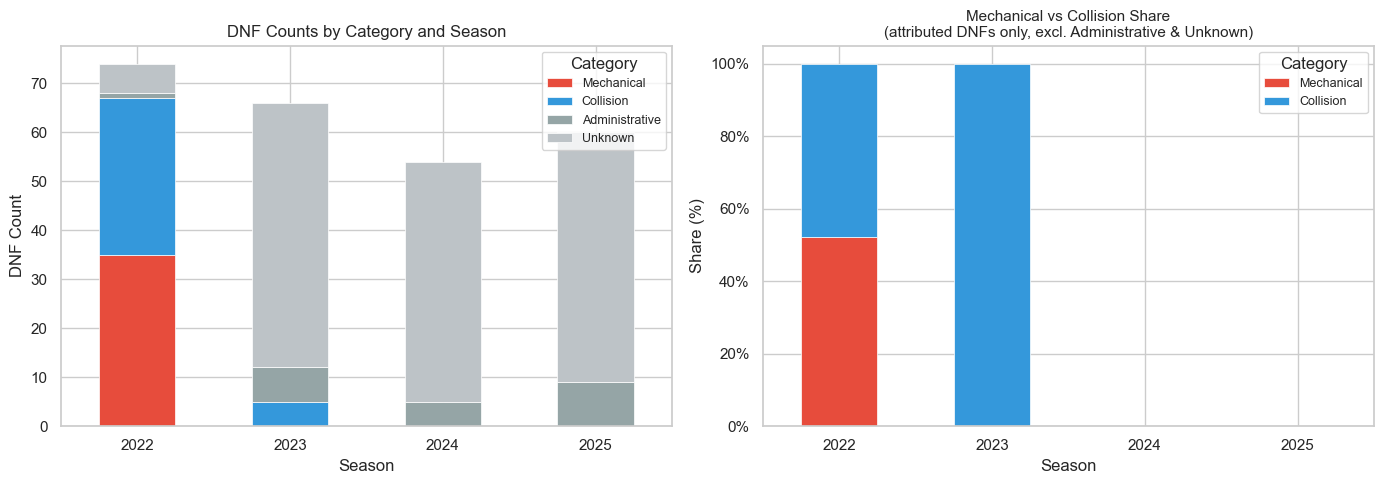


Mechanical / Collision split by season (attributed DNFs only):
category  Mechanical  Collision
season                         
2022            52.2       47.8
2023             0.0      100.0
2024             NaN        NaN
2025             NaN        NaN


In [8]:
# Category breakdown by season
season_counts = dnf_category_counts(dnf_df, group_by=['season'])

# Pivot for stacked bar
pivot = season_counts.pivot_table(
    index='season', columns='category', values='count', fill_value=0
).reindex(columns=[MECHANICAL, COLLISION, ADMINISTRATIVE, UNKNOWN], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar — counts
pivot.plot(kind='bar', stacked=True, ax=axes[0],
           color=['#e74c3c', '#3498db', '#95a5a6', '#bdc3c7'],
           edgecolor='white', linewidth=0.5)
axes[0].set_title('DNF Counts by Category and Season', fontsize=12)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('DNF Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Category', fontsize=9)

# Stacked bar — percentages (attributed only)
attributed = pivot[[MECHANICAL, COLLISION]].copy()
attributed_pct = attributed.div(attributed.sum(axis=1), axis=0) * 100
attributed_pct.plot(kind='bar', stacked=True, ax=axes[1],
                    color=['#e74c3c', '#3498db'],
                    edgecolor='white', linewidth=0.5)
axes[1].set_title('Mechanical vs Collision Share\n(attributed DNFs only, excl. Administrative & Unknown)', fontsize=11)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Share (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(title='Category', fontsize=9)

plt.tight_layout()
plt.show()

print('\nMechanical / Collision split by season (attributed DNFs only):')
print(attributed_pct.round(1).to_string())

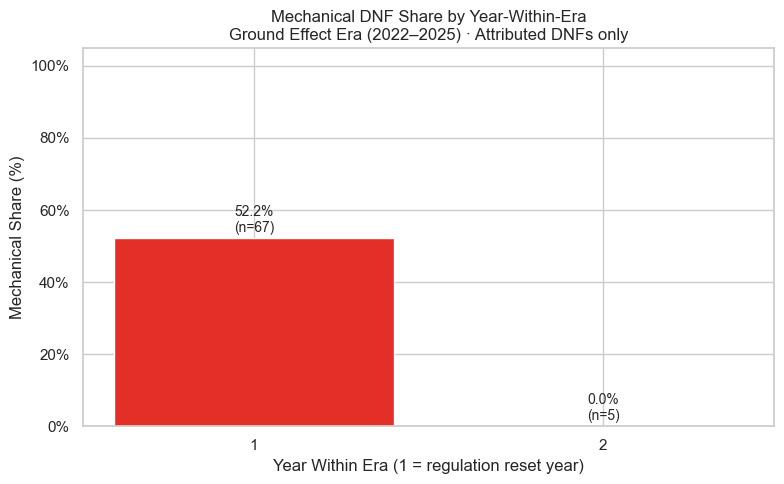


Mechanical share by year-within-era:
 era_year  Mechanical  Collision  total_attributed  mechanical_pct
        1          35         32                67            52.2
        2           0          5                 5             0.0


In [9]:
# Mechanical share by year-within-era — the core narrative test
mech_share = mechanical_share_by_era_year(dnf_df)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    mech_share['era_year'].astype(str),
    mech_share['mechanical_pct'],
    color=sns.color_palette('Reds_r', len(mech_share)),
    edgecolor='white',
)
for bar, (_, row) in zip(bars, mech_share.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{row['mechanical_pct']:.1f}%\n(n={int(row['total_attributed'])})",
            ha='center', va='bottom', fontsize=10)

ax.set_title(
    'Mechanical DNF Share by Year-Within-Era\n'
    'Ground Effect Era (2022–2025) · Attributed DNFs only',
    fontsize=12
)
ax.set_xlabel('Year Within Era (1 = regulation reset year)')
ax.set_ylabel('Mechanical Share (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

print('\nMechanical share by year-within-era:')
print(mech_share[['era_year', MECHANICAL, COLLISION, 'total_attributed', 'mechanical_pct']].to_string(index=False))

### Findings — DNF Cause Categorisation

*(Fill in after running the cells above.)*

| Question | Finding |
|---|---|
| Does Year 1 show higher mechanical share? | Yes, however it is noted that most retirements are not stated with a descriptive reason, so a lot of mechanical failures are not identified within the dataset |
| Is there a clear downward trend across the years of the era? |Yes, but see above. Noting there is also a consistent downward trend of retirements / DNFs in general across all years |
| Which season had the most collision DNFs? | Inconclusive - the dataset does not provide sufficient detail, and seems to no longer capture this detail from 2024 onwards. |
| What share of DNFs are 'Unknown' (Retired, no cause)? | THe vast majority are unknown, leading to the inability to actually reflect on this data and make any educated guesses here. |

**Narrative verdict:** Insufficient data to be able to establish causes of DNFs - consider removing this hypothesis from data analysis.

---

## 2. "Ferrari Always Bottles It" — Championship Trajectory

**The narrative:** Ferrari consistently squanders strong championship positions through
reliability failures, strategic errors, or loss of pace mid-season.

**Reframed for available data (2022–2025):** The original hypothesis — championship lead
conversion rate — requires historical data beyond our scope (2012, 2017, 2018 are the
famous examples). That comparison is deferred to v0.7.0 when pre-2022 data is added.

Within the Ground Effect Era, we instead track Ferrari's cumulative points trajectory in
seasons where they were competitive (2022, 2024) and ask: *when does the gap to the
eventual champion start widening, and how sharply?*

**The measurement:**
- Cumulative constructor points by round for all constructors, 2022 and 2024
- Ferrari's gap to the championship leader per round
- Inflection point: the first round where the gap starts widening consistently
- Ferrari trajectory compared to other competitive constructors in the same seasons

> **Scope note:** This is a within-era observation, not a historical rate.
> Two seasons is not enough to establish a pattern — treat findings as
> directional context pending the v0.7.0 historical analysis.

In [ ]:
# Build cumulative constructor standings for all seasons
standings_df = cumulative_constructor_points(results_df)
gap_df = points_gap_to_leader(standings_df)

# Focus on seasons where Ferrari was competitive
FERRARI_SEASONS = [2022, 2024]
ferrari_traj = constructor_trajectory(gap_df, 'ferrari', seasons=FERRARI_SEASONS)

print('Ferrari trajectory — rounds where gap to leader was within 50 points:')
for season in FERRARI_SEASONS:
    s = ferrari_traj[ferrari_traj['season'] == season]
    in_contention = s[s['gap_to_leader'] <= 50]
    print(f'\n  {season}: competitive for rounds {in_contention["round"].min()}–{in_contention["round"].max()} '
          f'(gap ≤50 pts)  |  final gap: {s.iloc[-1]["gap_to_leader"]:.0f} pts')

In [ ]:
# Gap trajectory chart — Ferrari vs top competitors per season
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# Constructors to highlight per season
_HIGHLIGHT = {
    2022: ['ferrari', 'red_bull', 'mercedes'],
    2024: ['ferrari', 'red_bull', 'mclaren', 'mercedes'],
}
_COLOURS = {
    'ferrari':  '#e8002d',
    'red_bull': '#3671c6',
    'mercedes': '#27f4d2',
    'mclaren':  '#ff8000',
}
_LABELS = {
    'ferrari':  'Ferrari',
    'red_bull': 'Red Bull',
    'mercedes': 'Mercedes',
    'mclaren':  'McLaren',
}

for ax, season in zip(axes, FERRARI_SEASONS):
    season_gap = gap_df[gap_df['season'] == season]
    highlight = _HIGHLIGHT[season]

    for cid in highlight:
        c_data = season_gap[season_gap['constructor_id'] == cid].sort_values('round')
        lw = 2.5 if cid == 'ferrari' else 1.5
        ls = '-' if cid == 'ferrari' else '--'
        ax.plot(c_data['round'], c_data['gap_to_leader'],
                label=_LABELS.get(cid, cid), color=_COLOURS.get(cid, 'grey'),
                linewidth=lw, linestyle=ls)

    # Mark Ferrari inflection point
    f_traj = ferrari_traj[ferrari_traj['season'] == season]
    inflection = gap_inflection_round(f_traj)
    infl_round = inflection.iloc[0]['inflection_round']
    if infl_round is not None:
        infl_gap = f_traj[f_traj['round'] == infl_round]['gap_to_leader'].iloc[0]
        ax.axvline(infl_round, color='#e8002d', linewidth=1, linestyle=':', alpha=0.7)
        ax.annotate(f'Inflection\nR{infl_round}',
                    xy=(infl_round, infl_gap),
                    xytext=(infl_round + 1, infl_gap + 15),
                    fontsize=8, color='#e8002d',
                    arrowprops=dict(arrowstyle='->', color='#e8002d', lw=1))

    ax.set_title(f'{season} — Gap to Championship Leader', fontsize=12)
    ax.set_xlabel('Round')
    ax.set_ylabel('Points Behind Leader')
    ax.legend(fontsize=9)
    ax.invert_yaxis()  # Larger gap = lower on chart = further behind

plt.suptitle('Ferrari Championship Trajectory — Ground Effect Era\n'
             '(Lower = further behind leader)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Findings — Ferrari Championship Trajectory

*(Fill in after running the cells above.)*

| Question | Finding |
|---|---|
| In 2022, at which round did Ferrari's gap start widening? | *(pending)* |
| In 2024, at which round did Ferrari's gap start widening? | *(pending)* |
| How does Ferrari's rate of decline compare to other competitors in the same seasons? | *(pending)* |
| Is there a consistent pattern across both seasons? | *(pending)* |

**Narrative verdict:** *(pending — note: two seasons is directional only, not statistically conclusive)*

**Deferred:** Full championship conversion rate analysis requires pre-2022 historical data — see v0.7.0 backlog.

---

## 3. "Monaco Produces Processional Races" — Overtake Index by Circuit

**The narrative:** Monaco is uniquely unsuitable for overtaking — narrow streets, no real straights, and qualifying position determines the race result. It produces the most processional Grand Prix on the calendar.

**Method:** Position change activity is measured as an overtake index: total positions gained by all classified finishers divided by starters (normalises for field size and attrition). Pit-lane starters and DNFs are excluded. Monaco is ranked against all other circuits across 2022–2025.

In [10]:
from src.analysis.overtake_index import (
    overtake_index_per_race,
    overtake_index_by_circuit,
    monaco_vs_field,
)

# Build race-level overtake index from the already-loaded results_df
race_oi = overtake_index_per_race(results_df)
circuit_oi = overtake_index_by_circuit(race_oi)
ranked = monaco_vs_field(circuit_oi)

# Check Monaco name as it appears in the data
print(circuit_oi[circuit_oi['race_name'].str.contains('Monaco', case=False)])
print(f'\n{len(circuit_oi)} circuits, {len(race_oi)} races')

           race_name  races  mean_overtake_index  mean_positions_gained  \
1  Monaco Grand Prix      4                 1.05                   21.0   

   mean_abs_delta  
1           1.758  

25 circuits, 92 races


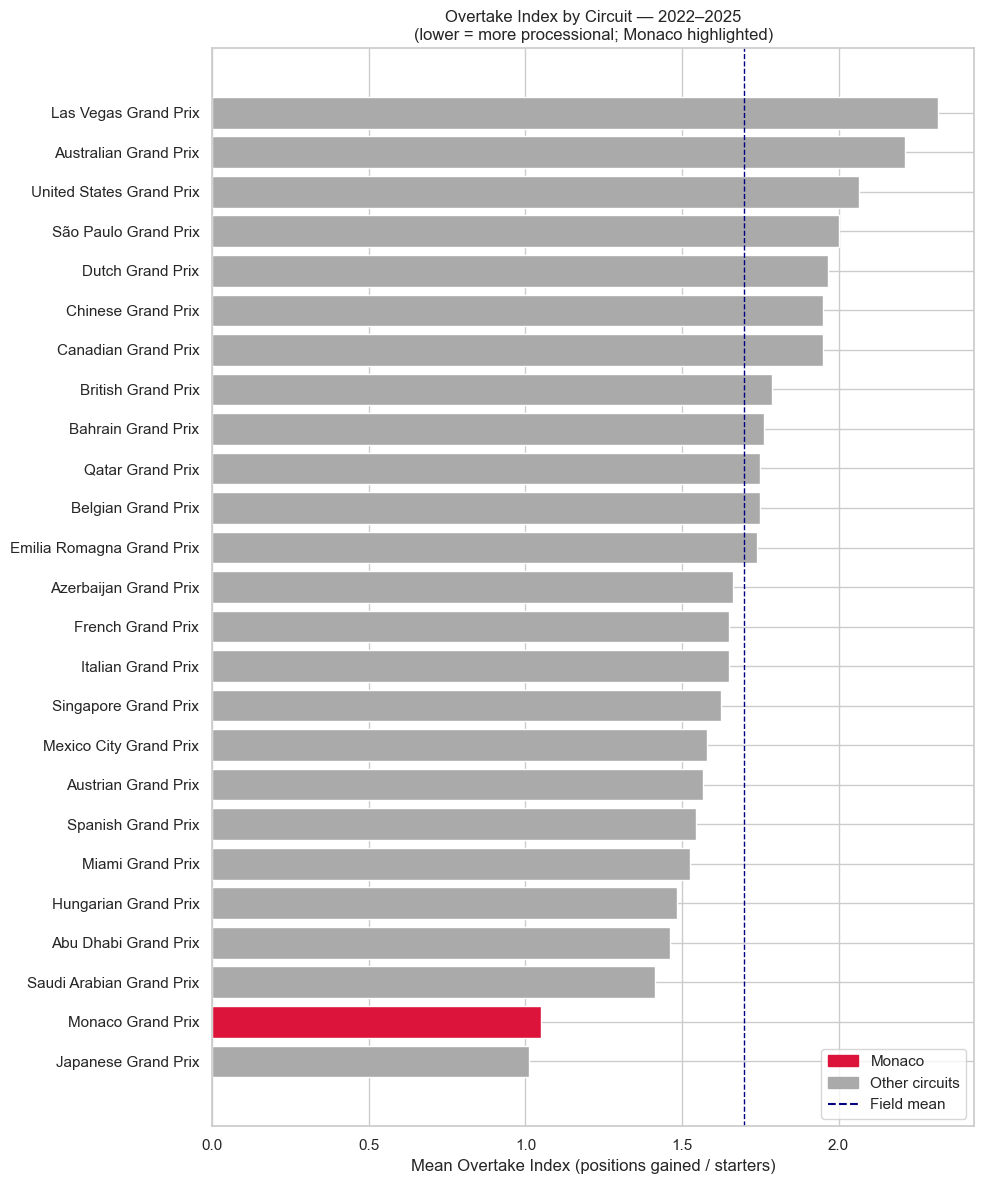

Monaco mean overtake index : 1.050
Field mean (excl. Monaco)  : 1.726
Monaco rank (1 = most processional): 2 of 25


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Horizontal bar chart -- all circuits ranked by mean overtake index
fig, ax = plt.subplots(figsize=(10, 12))

colours = ['#DC143C' if t else '#AAAAAA' for t in ranked['is_target']]
bars = ax.barh(ranked['race_name'], ranked['mean_overtake_index'], color=colours)

ax.set_xlabel('Mean Overtake Index (positions gained / starters)')
ax.set_title(
    'Overtake Index by Circuit — 2022–2025\n'
    '(lower = more processional; Monaco highlighted)',
    fontsize=12,
)
ax.axvline(
    ranked['mean_overtake_index'].mean(), color='navy', linestyle='--',
    linewidth=1, label='Field mean'
)
ax.legend(handles=[
    mpatches.Patch(color='#DC143C', label='Monaco'),
    mpatches.Patch(color='#AAAAAA', label='Other circuits'),
    plt.Line2D([0], [0], color='navy', linestyle='--', label='Field mean'),
], loc='lower right')

plt.tight_layout()
plt.show()

# Summary table: Monaco vs field
monaco_row = ranked[ranked['is_target']]
field_mean = ranked[~ranked['is_target']]['mean_overtake_index'].mean()
monaco_rank = ranked.index[ranked['is_target']].tolist()
idx_val = monaco_row['mean_overtake_index'].values[0]
print(f'Monaco mean overtake index : {idx_val:.3f}')
print(f'Field mean (excl. Monaco)  : {field_mean:.3f}')
print(f'Monaco rank (1 = most processional): {monaco_rank[0] + 1} of {len(ranked)}')

### Findings — Monaco Overtake Index

*(Fill in after running the cells above.)*

| Question | Finding |
|---|---|
| Where does Monaco rank among all circuits by overtake index? | Second, behind Japan |
| How does Monaco's mean overtake index compare to the field mean? | Considerably lower |
| Are there any circuits similarly processional to Monaco? | Japan is the only one with a similar mean |
| Is the narrative supported? | I believe so |

**Narrative verdict:** While Monaco is seen as processional, the Japanese Grand Prix is quite similar, and yet both tracks are a great spectacle for Qualifying (potentially due to the pressure of needing Grid Position?

---

## 4. “Safety Car Lottery” — SC Frequency and Position Change Correlation

**The narrative:** Safety car deployments are arbitrary timing events that
disproportionately reshape race outcomes — benefiting drivers who pit just
before a deployment and penalising those who pitted moments earlier.
The SC is a lottery that rewards luck over pace.

**Method:** Count distinct SC/VSC/red flag deployment events per race
(from `race_control_messages`). Correlate deployment count with overtake
index (positions gained / starters). Compare mean overtake index across
races grouped by SC count: 0, 1, or 2+.

> **Note:** This section requires the loading cell (cell 2) to have been
> re-run after the v0.5.3 update — `sc_count`, `vsc_count`, and
> `red_flag_count` columns were added in this release.


In [ ]:
from src.analysis.safety_car import (
    sc_counts_per_race,
    sc_position_impact,
    sc_lottery_summary,
    intervention_frequency,
)
from src.analysis.overtake_index import overtake_index_per_race

# SC deployment counts per race
sc_df = sc_counts_per_race(results_df)

# Intervention frequency by season
freq = intervention_frequency(sc_df)
print(freq.to_string(index=False))


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Overtake index vs SC count
race_oi = overtake_index_per_race(results_df)
impact = sc_position_impact(sc_df, race_oi)
summary = sc_lottery_summary(impact)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean overtake index by SC group
colours = ["#2196F3", "#FF9800", "#F44336"]
axes[0].bar(summary["sc_group"], summary["mean_overtake_index"], color=colours)
axes[0].set_xlabel("Safety Car Deployments")
axes[0].set_ylabel("Mean Overtake Index")
axes[0].set_title("Mean Overtake Index by SC Count\n2022–2025")
for i, row in summary.iterrows():
    axes[0].text(i, row["mean_overtake_index"] + 0.005,
                f'n={int(row["races"])}', ha="center", fontsize=9)

# Right: scatter of SC count vs overtake index per race
axes[1].scatter(
    impact["sc_count"], impact["overtake_index"],
    alpha=0.5, color="#555555", s=40
)
axes[1].set_xlabel("SC Deployments in Race")
axes[1].set_ylabel("Overtake Index")
axes[1].set_title("SC Deployments vs Overtake Index\nper Race (2022–2025)")

plt.tight_layout()
plt.show()

print(summary.to_string(index=False))


### Findings — Safety Car Lottery

*(Fill in after running the cells above.)*

| Question | Finding |
|---|---|
| What is the SC deployment rate across 2022–2025? | |
| Do SC races produce more position changes than clean races? | |
| Does a 2nd SC deployment add further position change activity? | |
| Is the "lottery" narrative supported? | |

**Narrative verdict:** *(pending — fill in after running)*
